Running 5 parallel iterations with K=2000 episodes each...
This may take several minutes...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


**************************************************
Running experiment
**************************************************
**************************************************
Running experiment
**************************************************
**************************************************
Experiment complete
**************************************************
**************************************************
Saving data
**************************************************
**************************************************
Running experiment
**************************************************
**************************************************
Experiment complete
**************************************************
**************************************************
Saving data
**************************************************
**************************************************
Running experiment
**************************************************
********************************************

[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.8min finished


  Best constant allocation total: 1.00 (per asset: 0.5000)
Estimated V*(x0) = 16.9933


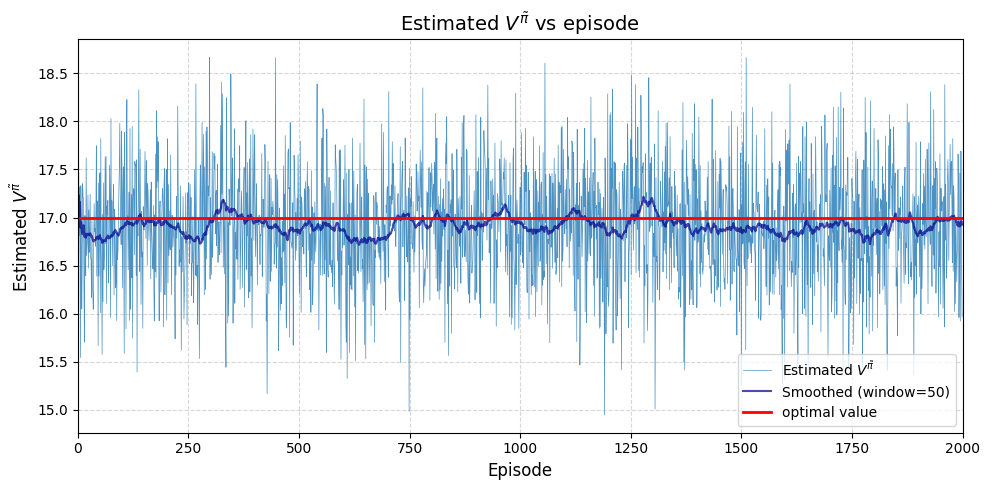

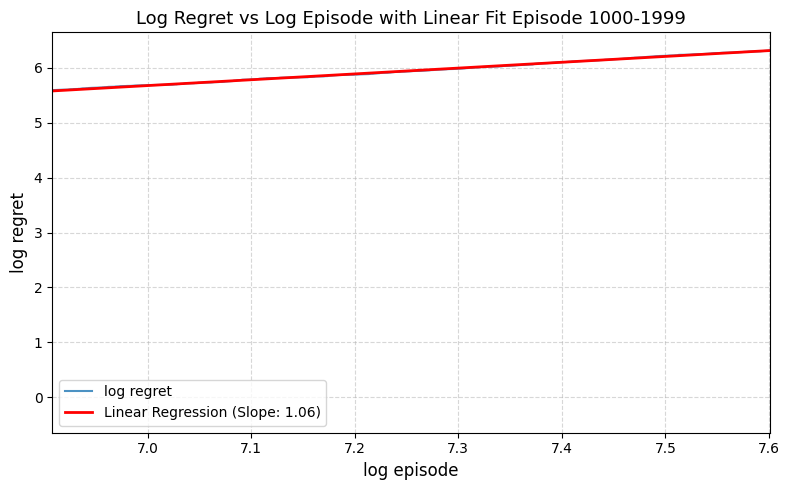


Regret order estimation:
  Slope = 1.0603
  R^2 = 0.9985
  This suggests cumulative regret ~ K^1.06

SUMMARY
  Episodes (K):            2000
  Horizon (H):             30
  Parallel runs:           5
  Starting state (X1):     2
  Optimal V*(x0):          16.9933
  Final avg reward (last 100): 16.9520
  Total cumulative regret: 550.43
  Regret slope:            1.0603


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy import stats
import importlib
import aaro_exp as ad
importlib.reload(ad)

# =============================================================================
# 1. Run the Experiment
# =============================================================================
n_runs = 5

print(f"Running {n_runs} parallel iterations with K={ad.nEps} episodes each...")
print("This may take several minutes...")

list_of_vpi = Parallel(n_jobs=-1, verbose=5)(
    delayed(ad.run_single_experiment_iteration)(i) for i in range(n_runs)
)

vpi_df = pd.DataFrame(list_of_vpi).T
vpi_estimate = vpi_df.mean(axis=1)

# =============================================================================
# 2. Compute Optimal Value V*(x0)
# =============================================================================
print("Computing optimal value V*(x0) via Monte Carlo...")
optimal_value = ad.compute_optimal_value(
    ad.starting_state, ad.epLen, ad.Delta
)
print(f"Estimated V*(x0) = {optimal_value:.4f}")

# =============================================================================
# 3. Plot (a): Estimated V^π vs Episode
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5))

episodes = np.arange(len(vpi_estimate))

ax.plot(episodes, vpi_estimate,
        color='tab:blue', linewidth=0.5, alpha=0.8,
        label=r'Estimated $V^{\tilde{\pi}}$')

window = 50
if len(vpi_estimate) >= window:
    smoothed = vpi_estimate.rolling(window=window, min_periods=1).mean()
    ax.plot(episodes, smoothed, color='darkblue', linewidth=1.5, alpha=0.7,
            label=f'Smoothed (window={window})')

ax.axhline(y=optimal_value, color='red', linewidth=2, label='optimal value')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(r'Estimated $V^{\tilde{\pi}}$', fontsize=12)
ax.set_title(r'Estimated $V^{\tilde{\pi}}$ vs episode', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim([0, ad.nEps])

plt.tight_layout()
plt.savefig('vpi_vs_episode.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. Plot (b): Log Regret vs Log Episode with Linear Fit
# =============================================================================
instantaneous_regret = np.maximum(optimal_value - vpi_estimate.values, 0)
cumulative_regret = np.cumsum(instantaneous_regret)

episodes_1idx = np.arange(1, len(cumulative_regret) + 1)

valid_mask = cumulative_regret > 0
log_episodes = np.log(episodes_1idx[valid_mask])
log_regret = np.log(cumulative_regret[valid_mask])

fit_start = 1000
fit_end = ad.nEps
fit_mask = ((episodes_1idx[valid_mask] >= fit_start) &
            (episodes_1idx[valid_mask] <= fit_end))

if np.sum(fit_mask) > 10:
    log_eps_fit = log_episodes[fit_mask]
    log_reg_fit = log_regret[fit_mask]

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        log_eps_fit, log_reg_fit
    )
    fit_line = slope * log_eps_fit + intercept

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(log_episodes, log_regret,
            color='tab:blue', linewidth=1.5, alpha=0.8, label='log regret')
    ax.plot(log_eps_fit, fit_line,
            color='red', linewidth=2,
            label=f'Linear Regression (Slope: {slope:.2f})')

    ax.set_xlim([np.log(fit_start), np.log(fit_end)])
    ax.set_xlabel('log episode', fontsize=12)
    ax.set_ylabel('log regret', fontsize=12)
    ax.set_title(
        f'Log Regret vs Log Episode with Linear Fit Episode {fit_start}-{fit_end-1}',
        fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('log_regret_vs_log_episode.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nRegret order estimation:")
    print(f"  Slope = {slope:.4f}")
    print(f"  R^2 = {r_value**2:.4f}")
    print(f"  This suggests cumulative regret ~ K^{slope:.2f}")
else:
    print("Not enough valid data points for linear regression on the specified range.")

# =============================================================================
# 5. Summary Statistics
# =============================================================================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Episodes (K):            {ad.nEps}")
print(f"  Horizon (H):             {ad.epLen}")
print(f"  Parallel runs:           {n_runs}")
print(f"  Starting state (X1):     {ad.starting_state}")
print(f"  Optimal V*(x0):          {optimal_value:.4f}")
print(f"  Final avg reward (last 100): {vpi_estimate.iloc[-100:].mean():.4f}")
print(f"  Total cumulative regret: {cumulative_regret[-1]:.2f}")
if np.sum(fit_mask) > 10:
    print(f"  Regret slope:            {slope:.4f}")
print("=" * 60)